In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.utils import resample
import random

from google.colab import drive, files
drive.mount('/content/drive')


"""

next steps:
    sequence of incoming signal
    1. collect signal into csv file
    2. read csv file and split existing data into R windows
    3. read each window and make a prediction
    4. repeat step 2 after a certain amount of time



"""


Mounted at /content/drive


'\n\nnext steps:\n    sequence of incoming signal\n    1. collect signal into csv file\n    2. read csv file and split existing data into R windows\n    3. read each window and make a prediction\n    4. repeat step 2 after a certain amount of time\n\n\n\n'

In [ ]:
# SETTINGS
data_folder = "/content/drive/MyDrive/ekg_data"
#data_folder = "/content/drive/My Drive/ekg_data"

fs = 360
lowcut = 0.5
highcut = 40
order = 3



In [ ]:
# @title

# Try window sampling instead of R-R interval
window_before = int(0.1 * fs)   # 100 ms
window_after  = int(0.15 * fs)  # 150 ms
def extract_beat_windows(y_filtered, r_waves):
    beats = []

    for r in r_waves:
        left = r - window_before
        right = r + window_after

        if left < 0 or right >= len(y_filtered):
            continue

        beat = y_filtered[left:right]
        beats.append(beat)

    return beats

In [ ]:
# @title
# Try window sampling instead of R-R interval
window_before = int(0.1 * fs)   # 100 ms
window_after  = int(0.15 * fs)  # 150 ms
def extract_beats_with_features(y, ann_times, ann_labels):
    y_f = bandpass_filter(y)
    r_waves, _ = find_peaks(y_f, height=0.5)

    rr_list = []
    labels = []
    beat_windows = []

    mean_rr = None

    for i in range(len(r_waves) - 1):

        r_current = r_waves[i]
        r_next = r_waves[i+1]

        # RR interval
        rr = y_f[r_current:r_next]

        # Window extraction
        left = r_current - window_before
        right = r_current + window_after

        if left < 0 or right >= len(y_f):
            continue   # skip everything if window invalid

        beat = y_f[left:right]

        # Label alignment
        idx = np.argmin(np.abs(ann_times - (r_current / fs)))
        label = beats_labelling(str(ann_labels[idx]))

        rr_list.append(rr)
        labels.append(label)
        beat_windows.append(beat)

    return rr_list, labels, beat_windows

In [ ]:
# BEATS LABELLING
#lbl_file = os.path.join(data_folder, "annotation_symbols.csv")
#symbols = pd.read_csv(
#    lbl_file,
#    header=None,
#    usecols=[0]
#).iloc[2:, 0].astype(str).str.strip().tolist()
#print(type(symbols[2]))
#label_to_int = {sym: i for i, sym in enumerate(symbols)}
normal_beats = ['n','l','r','e','j']

def beats_labelling(labels):
    if isinstance(labels, str):
        label=labels.lower()
    return 0 if label in normal_beats else 1

In [ ]:
# BANDPASS FILTER FUNCTION
def bandpass_filter(signal):
    nyq = 0.5*fs
    b,a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b,a,signal)

In [ ]:
# DOWNSAMPLING
def downsample(signal, orig_fs=360, target_fs=180):
    num_samples = int(len(signal) * target_fs / orig_fs)
    return resample(signal, num_samples)

In [ ]:
# LOAD PATIENT DATA
def load_patient(record_name):
    ecg_file = os.path.join(data_folder, f"{record_name}_ekg.csv")
    ann_file = os.path.join(data_folder, f"{record_name}_annotations_1.csv")

    df = pd.read_csv(ecg_file)
    df_ann = pd.read_csv(ann_file)

    x = df.iloc[:,0].values
    y = df.iloc[:,1].values
    #y = downsample(y)
    fs = 180
    ann_times = df_ann.iloc[:,0].values
    ann_labels = df_ann.iloc[:,1].values
    return x, y, ann_times, ann_labels


In [ ]:
# @title
# GET R-R INTERVALS + LABELS
def get_rr_intervals(y, ann_times, ann_labels):
    y_f = bandpass_filter(y)
    r_waves, _ = find_peaks(y_f, height=0.5)

    rr_list = []
    rr_labels = []

    for i in range(len(r_waves)-1):
        rr = y_f[r_waves[i]:r_waves[i+1]]
        rr_list.append(rr)
        idx = np.argmin(np.abs(ann_times - (r_waves[i+1]/fs)))
        label = str(ann_labels[idx])
        rr_labels.append(beats_labelling(label))

    return rr_list, rr_labels, r_waves, y_f

In [ ]:
# @title
#Try beat features for windows
def beat_features(rr, labels, beat_windows):
    x, y = [], []

    mean_rr = np.mean([len(r) for r in rr])

    for i in range(len(rr)):
        rr_len = len(rr[i])
        rr_prev = len(rr[i-1]) if i > 0 else rr_len
        rr_next = len(rr[i+1]) if i < len(rr)-1 else rr_len
        amp = np.max(rr[i]) - np.min(rr[i])

        base_features = [
            rr_len,
            rr_prev,
            rr_next,
            rr_len / rr_prev,
            rr_len / rr_next,
            rr_len / mean_rr,
            amp
        ]

        beat = beat_windows[i]
        beat = beat - np.mean(beat)
        beat = beat / (np.std(beat) + 1e-8)

        shape_features = [
            np.mean(beat),
            np.std(beat),
            np.max(beat),
            np.min(beat),
            np.ptp(beat),
            np.sum(np.abs(np.diff(beat))),  # slope energy
            np.argmax(beat),                # R peak position in window
        ]

        full_features = base_features + shape_features

        x.append(full_features)
        y.append(labels[i])

    return x, y

In [ ]:
# @title
#PAUSE

# STATISTICAL FEATURES
#use statistical features for training...

def beat_features(rr, labels):
    x, y =[], []
    mean_rr = np.mean([len(r) for r in rr])

    for i in range(len(rr)):
        rr_len = len(rr[i])
        rr_prev = len(rr[i-1]) if i > 0 else rr_len
        rr_next = len(rr[i+1]) if i < len(rr)-1 else rr_len
        amp = np.max(rr[i]) - np.min(rr[i])

        base_features = [
            rr_len,
            rr_prev,
            rr_next,
            rr_len / rr_prev,
            rr_len / rr_next,
            rr_len / mean_rr,
            amp
        ]

        beat = rr[i]
        beat = beat - np.mean(beat)
        beat = beat / (np.std(beat) + 1e-8)

        shape_features = [
            np.mean(beat),
            np.std(beat),
            np.max(beat),
            np.min(beat),
            np.ptp(beat),
            np.sum(np.abs(np.diff(beat))),  # slope energy
        ]

        full_features = base_features + shape_features

        x.append(full_features)
        y.append(labels[i])

    return x, y

In [ ]:
# SELECT PATIENTS
patients = sorted([f.replace("_ekg.csv","")
                   for f in os.listdir(data_folder) if "_ekg.csv" in f])

#random.shuffle(patients)
#Tried shuffling and oh my god the val accuracy was 3% aand testing was 30% :o
#so now we will choose exactly which patients
#patients = ['103', '208', '209', '207', '201', '234', '233', '228', '223', '221', '220', '105', '117', '116', '107', '102', '230', '205', '115', '214', '104', '215', '232', '123', '212', '231', '210', '119', '114', '217', '200', '222', '203', '122', '106', '213', '112', '109', '202', '219', '121', '113', '108', '101', '124', '100', '111', '118']
train_patients = patients[:32]
val_patients  = patients[32:42]
test_patients = patients[42:]
#train_patients = ['101', '106', '108', '109', '112', '114', '115', '116', '118', '119', '122', '124', '201', '203', '205', '207', '208', '209', '215', '220', '223', '230']
#val_patients = ['100', '103', '105', '111', '113', '117', '121', '123', '200', '202', '210', '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234']
#test_patients = ['102', '104', '107', '217']

#train_patients = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '232', '233']
#val_patients = ['212', '213', '214', '215', '217', '219', '220', '221', '222', '223']
#test_patients = ['228', '230', '231', '234']

In [ ]:
print(train_patients)
print(val_patients)
print(test_patients)


['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210']
['212', '213', '214', '215', '217', '219', '220', '221', '222', '223']
['228', '230', '231', '232', '233', '234']


In [ ]:
 # SPLIT PATIENTS
#num_patients = len(train_patients)
#IDRK what happening here so i'm jsut gonna put some numbers down
#train_split = int(num_patients)
#val_split   = int(num_patients) + train_split

#train_group = train_patients[:train_split]
#val_group   = train_patients[train_split:val_split]
#test_group  = train_patients[val_split:]
train_group = train_patients
val_group   = val_patients
test_group  = test_patients
print("Train patients:", len(train_group))
print("Validation patients:", len(val_group))
print("Test patients:", len(test_group))


Train patients: 32
Validation patients: 10
Test patients: 6


In [ ]:
# TRAINING DATA (feature = R-R interval length)
x_train, y_train, x_val, y_val = [], [], [], []

for p in train_patients:
    t, y, ann_t, ann_l = load_patient(p)
    rr, labels, r_waves, y_f = get_rr_intervals(y, ann_t, ann_l)
    x_p, y_p = beat_features(rr, labels)
    #beat_windows = extract_beat_windows(y_f, r_waves)
    #rr, labels, beat_windows = extract_beats_with_features(y, ann_t, ann_l)
    #x_p, y_p = beat_features(rr, labels, beat_windows)

    x_train.extend(x_p)
    y_train.extend(y_p)

x_train = np.array(x_train)
y_train = np.array(y_train)

#BOOTSTRAPPING
df = pd.DataFrame(x_train)
df['label'] = y_train

df_majority = df[df.label == 0]
df_minority = df[df.label == 1]

print("Before balancing:")
print(df['label'].value_counts())

#Bootstrapping the minority class
df_minority_boot = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

# Combine and shuffle
df_balanced = pd.concat([df_majority, df_minority_boot])
df_balanced = df_balanced.sample(frac=1, random_state=42)

x_train = df_balanced.drop('label', axis=1).values
y_train = df_balanced['label'].values

print("After balancing:")
print(pd.Series(y_train).value_counts())


Before balancing:
label
0    58147
1    19144
Name: count, dtype: int64
After balancing:
0    58147
1    58147
Name: count, dtype: int64


In [ ]:
# TRAIN MODEL
clf = RandomForestClassifier(
    class_weight={0:1, 1:3},
    random_state=42,
    n_estimators=400)
clf.fit(x_train, y_train)
print("Model trained on " + str(len(train_group)) + " patients.")

Model trained on 32 patients.


In [ ]:
# GET R-R INTERVALS for real time
def get_rr_intervals_rt(y):
    y_f = bandpass_filter(y)
    amplitude = []
    r_waves, amplitude = find_peaks(y_f, height=0.5)

    rr_list = []

    for i in range(len(r_waves)-1):
        rr = y_f[r_waves[i]:r_waves[i+1]]
        rr_list.append(rr)

    return rr_list, r_waves, amplitude['peak_heights']

In [ ]:
# STATISTICAL FEATURES for real time
def beat_features_rt(rr):
    x = []
    mean_rr = np.mean([len(r) for r in rr])

    for i in range(len(rr)):
        rr_len = len(rr[i])
        rr_prev = len(rr[i-1]) if i > 0 else rr_len
        rr_next = len(rr[i+1]) if i < len(rr)-1 else rr_len
        amp = np.max(rr[i]) - np.min(rr[i])

        base_features = [
            rr_len,
            rr_prev,
            rr_next,
            rr_len / rr_prev,
            rr_len / rr_next,
            rr_len / mean_rr,
            amp
        ]

        beat = rr[i]
        beat = beat - np.mean(beat)
        beat = beat / (np.std(beat) + 1e-8)

        shape_features = [
            np.mean(beat),
            np.std(beat),
            np.max(beat),
            np.min(beat),
            np.ptp(beat),
            np.sum(np.abs(np.diff(beat))),  # slope energy
        ]

        full_features = base_features + shape_features

        x.append(full_features)

    return x

In [ ]:
#Create results for website display
#include three outputs: Time stamp, Amplitude, Annotation

x_res = []
#y_res = []

#Sample patient
res_group = ['212']

for p in res_group:
    #load patient for real time update
    t, y, _, _ = load_patient(p)
    #t, y, ann_t, ann_l = load_patient(p)
    #rr, labels, _, _ = get_rr_intervals(y, ann_t, ann_l)
    #x_p, y_p = beat_features(rr, labels)
    rr, time_stamp, amplitude = get_rr_intervals_rt(y)
    x_p = beat_features_rt(rr)

    x_res.extend(x_p)
    #y_res.extend(y_p)

x_res = np.array(x_res)

res_pred = clf.predict(x_res)
#res_acc = accuracy_score(y_res, res_pred)

#print("Validation accuracy:", res_acc)

time_stamp=time_stamp[:-1]
amplitude=amplitude[:-1]


output = {'Predictions':res_pred, 'Time Stamp': time_stamp, 'Amplitude': amplitude}
res_df = pd.DataFrame(output)

res_df.to_csv("results.csv", index=False)
files.download("results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from collections import Counter
print(Counter(y_train))

Counter({np.int64(0): 60934, np.int64(1): 60934})


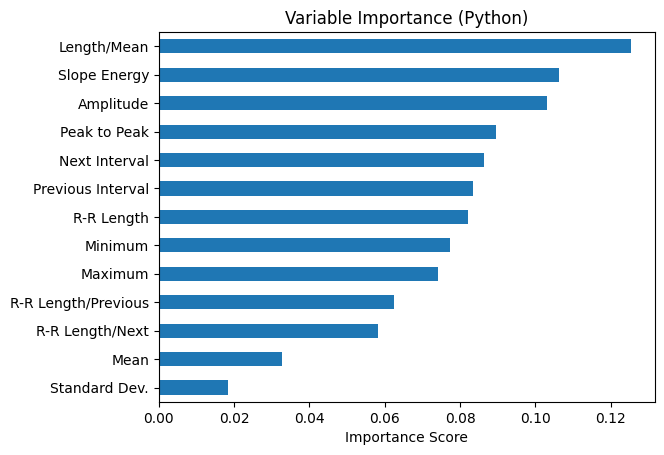

In [ ]:
importances = clf.feature_importances_
feature_names = ['R-R Length', 'Previous Interval', 'Next Interval', 'R-R Length/Previous','R-R Length/Next','Length/Mean','Amplitude','Mean','Standard Dev.', 'Maximum', 'Minimum','Peak to Peak','Slope Energy']
forest_importances = pd.Series(importances, index=feature_names)

forest_importances.sort_values().plot.barh()
plt.title("Variable Importance (Python)")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
# VALIDATION
x_val, y_val = [], []

for p in val_group:
    t, y, ann_t, ann_l = load_patient(p)
    rr, labels, _, _ = get_rr_intervals(y, ann_t, ann_l)
    x_p, y_p = beat_features(rr, labels)
    #rr, labels, beat_windows = extract_beats_with_features(y, ann_t, ann_l)

    #x_p, y_p = beat_features(rr, labels, beat_windows)
    x_val.extend(x_p)
    y_val.extend(y_p)

x_val = np.array(x_val)
y_val = np.array(y_val)

val_pred = clf.predict(x_val)
val_acc = accuracy_score(y_val, val_pred)

print("Validation accuracy:", val_acc)


Validation accuracy: 0.780154289309009


In [ ]:
# TEST EVALUATION
x_test, y_test = [], []
patient_names = []
patient_accuracies = []
t_test = None
y_f_test = None
r_waves_test = None

for p in test_group:
    t, y, ann_t, ann_l = load_patient(p)

    rr, labels, r_waves, y_filtered = get_rr_intervals(y, ann_t, ann_l)
    #rr, labels, beat_windows = extract_beats_with_features(y, ann_t, ann_l)

    # Save these ONLY from the last test patient for plotting
    t_test = t
    y_f_test = y_filtered
    #y_f_test = beat_windows
    r_waves_test = r_waves
    x_p, y_p = [], []

    mean_rr = np.mean([len(r) for r in rr])

    for i in range(len(rr)):
        rr_len = len(rr[i])
        rr_prev = len(rr[i-1]) if i > 0 else rr_len
        rr_next = len(rr[i+1]) if i < len(rr)-1 else rr_len
        amp = np.max(rr[i]) - np.min(rr[i])

        base_features = [
            rr_len,
            rr_prev,
            rr_next,
            rr_len / rr_prev,
            rr_len / rr_next,
            rr_len / mean_rr,
            amp
        ]

        beat = rr[i]
        beat = beat - np.mean(beat)

        shape_features = [
            np.mean(beat),
            np.std(beat),
            np.max(beat),
            np.min(beat),
            np.ptp(beat),
            np.sum(np.abs(np.diff(beat))),  # slope energy
        ]

        full_features = base_features + shape_features

        x_test.append(full_features)
        y_test.append(labels[i])

        x_p.append(full_features)
        y_p.append(labels[i])

    x_p = np.array(x_p)
    y_p = np.array(y_p)
    pred_p = clf.predict(x_p)

    # Store accuracy
    acc_p = accuracy_score(y_p, pred_p)
    patient_names.append(p)
    patient_accuracies.append(acc_p)


x_test = np.array(x_test)
y_test = np.array(y_test)

#test_pred = clf.predict(x_test)
probs = clf.predict_proba(x_test)[:,1]
test_pred = (probs > 0.35).astype(int)
test_acc = accuracy_score(y_test, test_pred)

print("Test accuracy (FINAL OVERALL ACCURACY):", test_acc)

Test accuracy (FINAL OVERALL ACCURACY): 0.765256588072122


In [ ]:
from collections import Counter
print("Predicted distribution:", Counter(test_pred))
print("True distribution:", Counter(y_test))

Predicted distribution: Counter({np.int64(0): 13002, np.int64(1): 1418})
True distribution: Counter({np.int64(0): 11101, np.int64(1): 3319})


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred))

[[10359   742]
 [ 2643   676]]
              precision    recall  f1-score   support

           0       0.80      0.93      0.86     11101
           1       0.48      0.20      0.29      3319

    accuracy                           0.77     14420
   macro avg       0.64      0.57      0.57     14420
weighted avg       0.72      0.77      0.73     14420



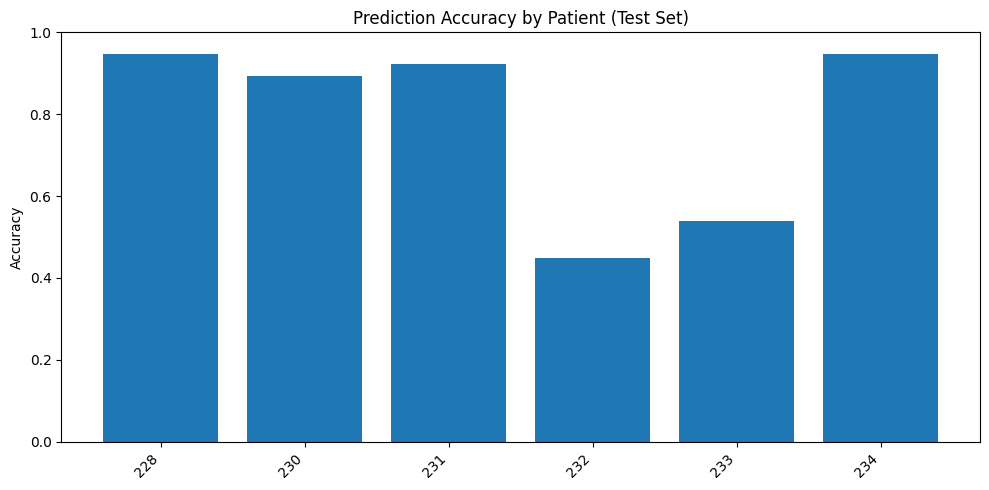

In [ ]:
# PLOT ACCURACY FOR EACH PATIENT
plt.figure(figsize=(10, 5))
plt.bar(patient_names, patient_accuracies)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Prediction Accuracy by Patient (Test Set)")
plt.tight_layout()
plt.show()

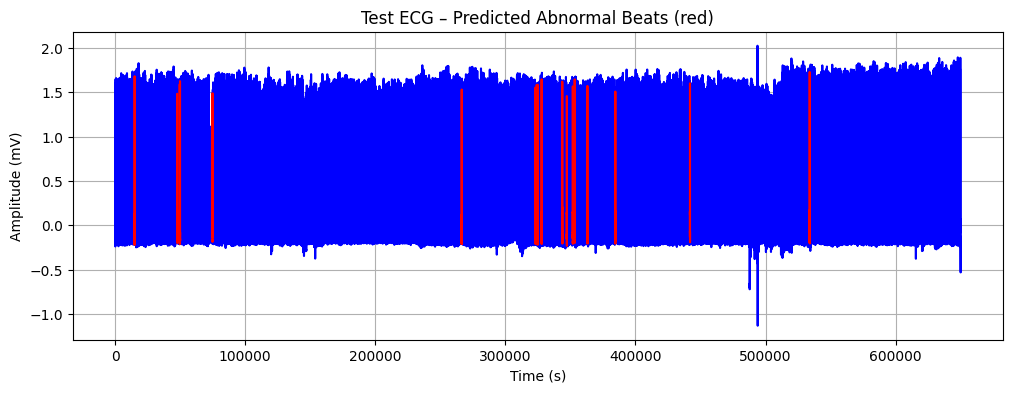

In [ ]:
# PLOT 1/4 OF ECG WITH ABNORMAL BEATS
N = len(y_f_test)    # Plot only first quarter
window = 50              # same as before (change if needed)

plt.figure(figsize=(12,4))
plt.plot(t_test[:N], y_f_test[:N], color='blue', label='Filtered ECG')

for i, p in enumerate(r_waves_test):
    if p >= N:
        continue
    if test_pred[i] == 1:   # <-- updated from y_pred → test_pred
        left = max(p - window, 0)
        right = min(p + window, N-1)
        plt.plot(t_test[left:right], y_f_test[left:right], color='red')

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Test ECG – Predicted Abnormal Beats (red)")
plt.grid(True)
plt.show()
